# DTEx231D. LodeSTAR to Detect the Cells in the BF-C2DT-HSC Dataset

<a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/LodeSTAR/03.track_BF-C2DL-HSC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack deeplay  # Uncomment if running on Colab/Kaggle

This example shows how to set up and train a LodeSTAR model to detect cells.

In [2]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Downloading the Data from the Cell Tracking Challenge.

In [3]:
import os

from torchvision.datasets.utils import _extract_zip, download_url


dataset_path = "./cell_detection_dataset/"
if not os.path.exists(dataset_path):
    url = (
        "http://data.celltrackingchallenge.net/training-datasets/"
        "BF-C2DL-HSC.zip"
    )
    download_url(url, ".")
    _extract_zip("BF-C2DL-HSC.zip", dataset_path, None)
    os.remove("BF-C2DL-HSC.zip")
directory = os.path.join(dataset_path, "BF-C2DL-HSC/02")

## 2. Loading the Data

In [4]:
from PIL import Image


def load_tif_movie(directory):
    """Loads Data."""

    tif_files = sorted(
        [
            os.path.join(directory, f)
            for f in os.listdir(directory)
            if f.lower().endswith(".tif")
        ]
    )
    frames = [np.array(Image.open(f)) for f in tif_files]

    movie = np.stack(frames, axis=0)

    return movie

Define normalization function.

In [5]:
def normalize_min_max(movie):
    """Normalizes intensities."""

    max_intensity = np.max(movie)
    min_intensity = np.min(movie)

    normalized_movie = (movie - min_intensity) / (
        max_intensity - min_intensity
    )

    return normalized_movie

Load the data from the directory and normalize it.

In [6]:
movie = load_tif_movie(directory)

movie = normalize_min_max(movie)

print(
    f"Loaded {movie.shape[0]} frames of size {movie.shape[1]}x{movie.shape[2]}"
)

Loaded 1764 frames of size 1010x1010


Visualize the data with a sample video.

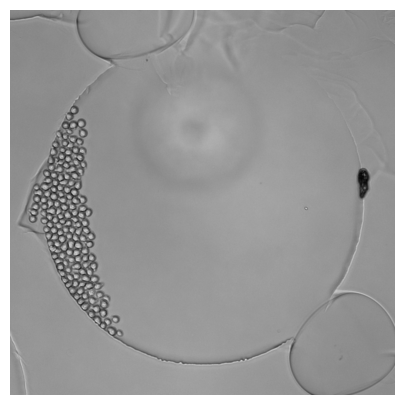

In [7]:
import matplotlib as mpl
from IPython.display import HTML, display

fig = plt.figure(figsize=(5, 5))
images = []
plt.axis("off")

# Plot every 50th frame.
for image in movie[::50]:
    images.append([
        plt.imshow(image[:, :], cmap="gray", animated=True)
    ])

anim = mpl.animation.ArtistAnimation(
    fig,
    images,
    interval=1000 / 10,  # 10 fps for the displayed frames
    blit=True,
    repeat_delay=0
)

display(HTML(anim.to_jshtml()))

## 3. Cropping a Cell

Crop a small window from the video.

In [8]:
t, x, y, w = (251, 80, 538, 40)
crop = movie[t, y : y + w, x : x + w]

Verify the shape of the crop.

In [9]:
print(f"Crop shape = {crop.shape}")

Crop shape = (40, 40)


Plot the crop.

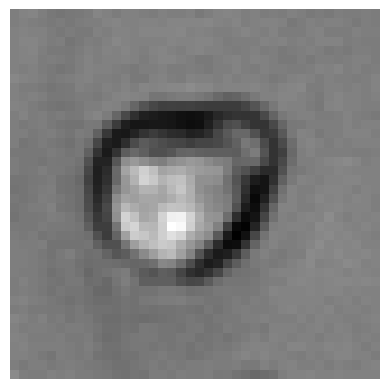

In [10]:
plt.imshow(crop, cmap="gray")
plt.axis("off")
plt.show()

## 4. Training LodeSTAR

Instance LodeSTAR ...

In [11]:
model = dl.LodeSTAR(n_transforms=8, optimizer=dl.Adam(lr=1e-4)).build()

... define training pipeline, dataset, and dataloader ...

In [12]:
training_crop = crop[np.newaxis]  # Add empty batch dimension

training_pipeline = (
    dt.Value(training_crop)
    >> dt.Add(lambda: np.random.randn() * 0.1)
    >> dt.Gaussian(sigma=lambda: np.random.uniform(0, 0.2))
    >> dt.Multiply(lambda: np.random.uniform(0.6, 1.2))
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)
train_dataset = dt.pytorch.Dataset(
    training_pipeline,
    length=512,
    replace=False,
)
dataloader = dl.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
)

... train it ...

In [13]:
trainer_lodestar = dl.Trainer(max_epochs=30, accelerator="auto")
trainer_lodestar.fit(model, dataloader)

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
W0728 14:55:23.290000 7780 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

... plot training history ...

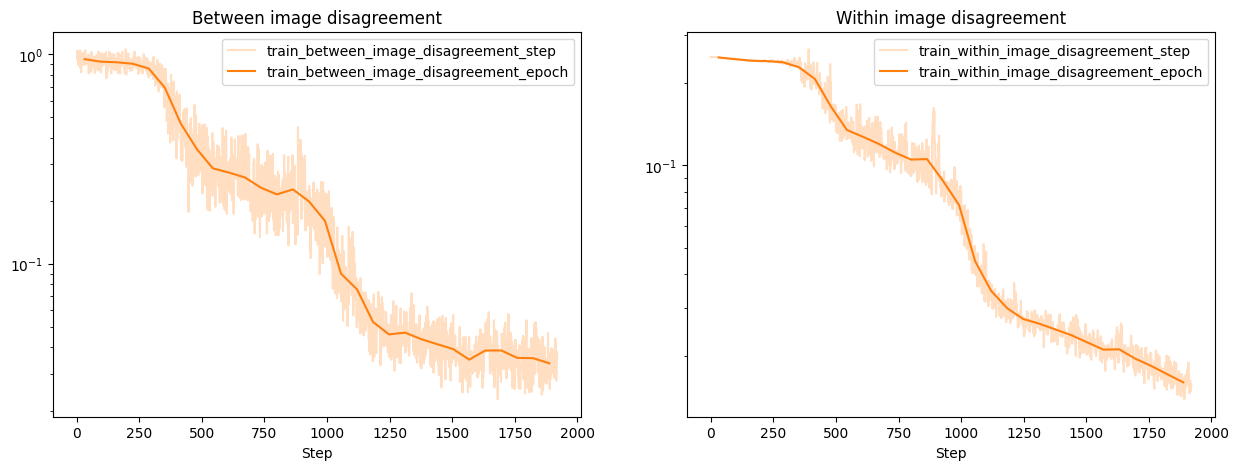

In [14]:
trainer_lodestar.history.plot();

... and save weights.

In [15]:
torch.save(model.state_dict(), f"{directory}/lodestar_weights_BF-C2DL-HSC.pth")

## 5. Testing the Model

Extract the last frame of the movie ...

In [16]:
frame_index = 1763

image = movie[frame_index]

image = image[130:-130, :400]  # Crop to focus on the cells

... convert the image to tensor for LodeSTAR ...

In [17]:
image = (
    torch.as_tensor(image, dtype=torch.float32)
    .detach()
    .unsqueeze(0)
    .unsqueeze(0)
    .to(model.device)
)

... execute LodeSTAR (may need to tune the parameters to get optimal performance) ...

In [18]:
alpha = 0.1
cutoff = 0.97

detections = model.detect(
    image, alpha=alpha, beta=1 - alpha, cutoff=cutoff, mode="quantile"
)[0]

... and plot the result.

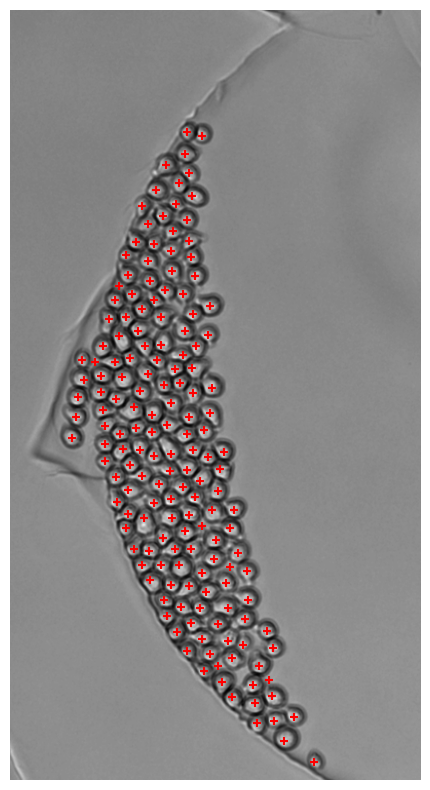

In [19]:
plt.figure(figsize=(10, 10))
plt.imshow(image.cpu()[0, 0, :, :], cmap="gray")
plt.axis("off")
plt.scatter(detections[:, 1], detections[:, 0], color="r", marker="+")
plt.show()